In [1]:
import xarray
import pygmt
import pandas
import numpy as np

## This is global map figure

In [2]:
# valid only for variables with following shape: (loc).

vname='cltatlid'
vmin=0.
vmax=100.

### internal work

In [3]:
ds = xarray.open_dataset("../data/MIROC_outputs/ctrl_MIROC-COSP2.nc")

In [4]:
%%capture

var=ds[vname].values

lat=ds["latitude"].values
lon=ds["longitude"].values

In [5]:
mask = (var >= vmin) & (var <= vmax)
data = np.column_stack([lon[mask], lat[mask], var[mask]])

In [6]:
check_rows = np.isfinite(data).all(axis=1)
Nerror = np.where(~check_rows)[0]

if Nerror.size > 0:
    raise ValueError("invalid data")

if data.size == 0:
    raise RuntimeError("no valid points")

In [7]:
fig = pygmt.Figure()
region = [-180, 180, -75, 75]

In [8]:
tbl_block = pygmt.blockmean(
    data=data,
    region=region,
    spacing="1.5d"
)

grid = pygmt.surface(
    data=tbl_block,
    region=region,
    spacing="1.5d"
)

In [9]:
gxyz = pygmt.xyz2grd(
    data=data,
    region=region,
    spacing="1.5d",
)

In [10]:
fig.coast(
    region=region,
    projection="W15c",
    frame="afg",
    land="lightgray",
    water="white"
)


In [11]:
fig.grdimage(
    grid=gxyz,
    cmap="turbo"
)

In [12]:
fig.colorbar(frame='af+l"Total Cloud Cover (%)"')

### result

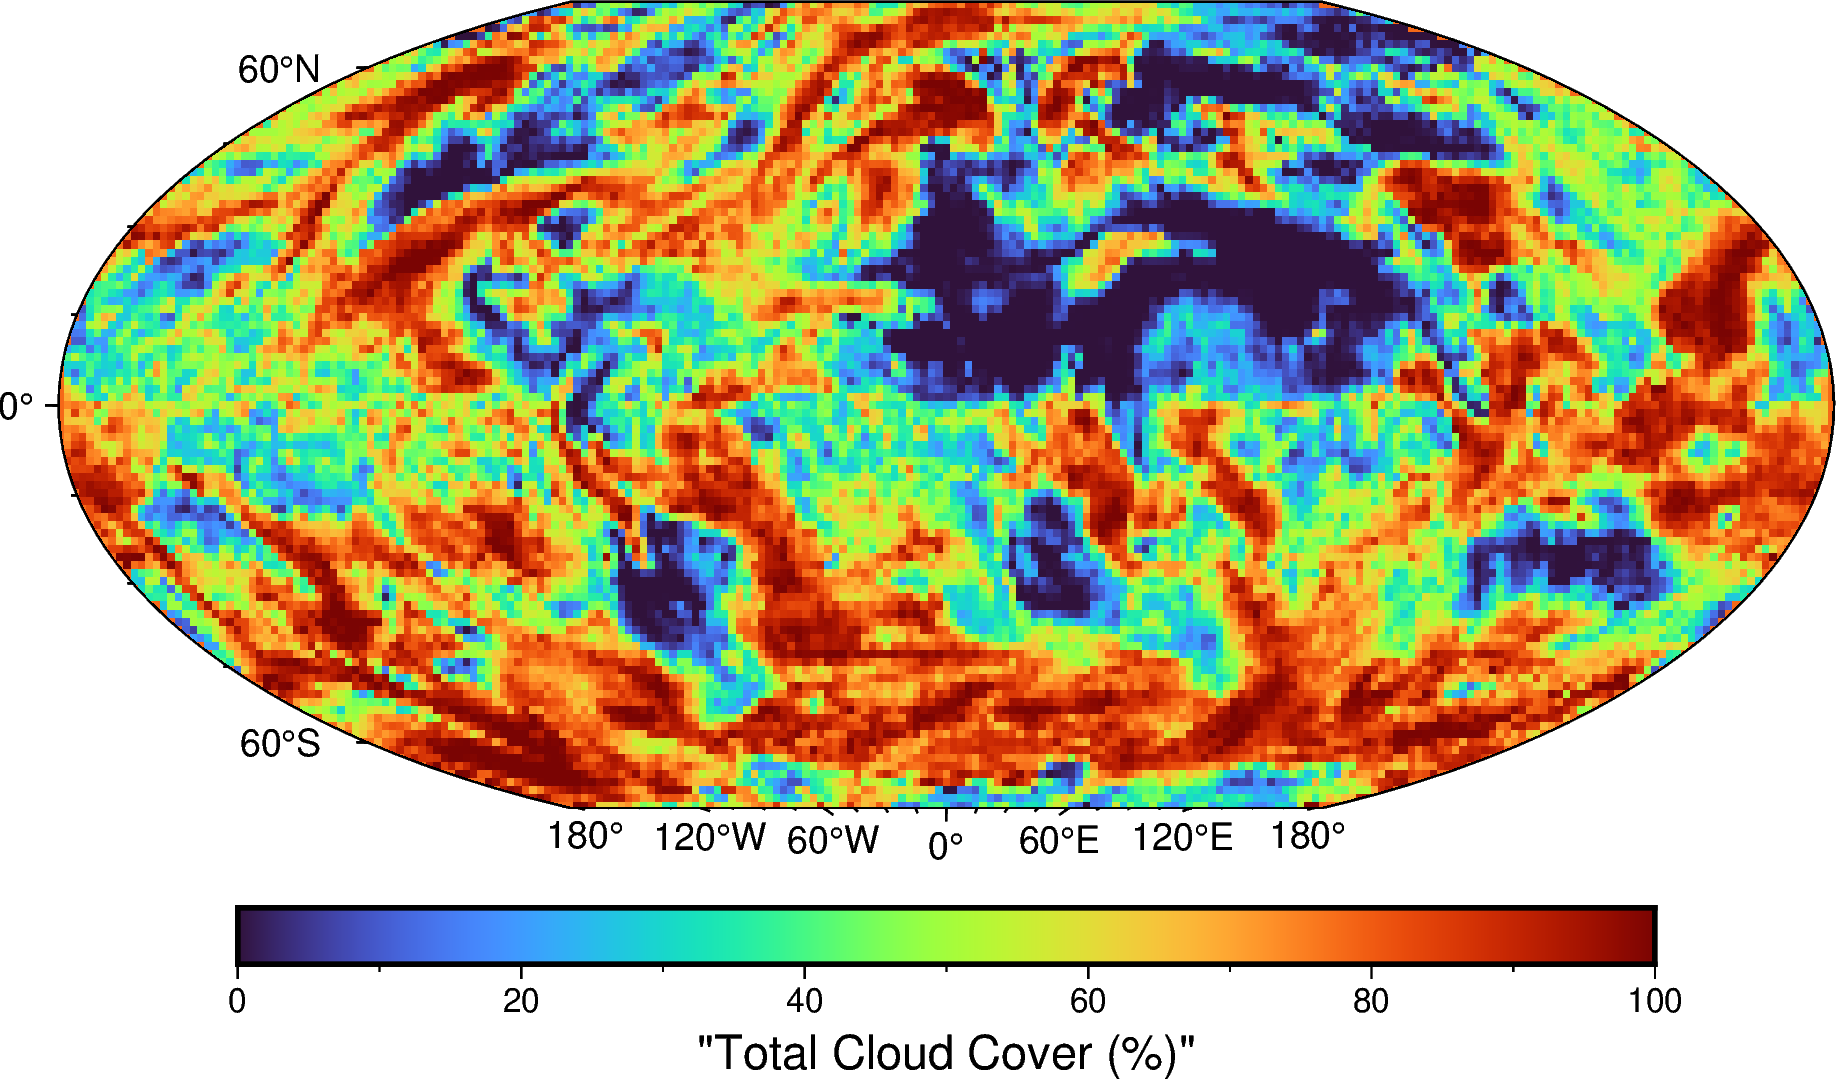

In [16]:
fig.show(width="80%")